AYEBIE GRAM MESCHAC

2000250045

ASSIGNMENT 5 (WINE)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
wine = pd.read_csv("C:/Users/Meschac/Desktop/ASSIGNMENT/wine.csv")

Data Preparation & Exploration

In [3]:
# display of the 5 first observations of te data
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,bad
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,bad
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,bad
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,good
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,bad


In [4]:
wine.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,bad
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,good
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,good
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,bad
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,good


In [5]:
# display of the data size
wine.shape

(1599, 12)

Our dataset has 1599 observations and 12 features

In [6]:
# data information and check missing values
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   object 
dtypes: float64(11), object(1)
memory usage: 150.0+ KB


11 features of the datset are all float and one object dataset and no missing values

In [7]:
wine.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [8]:
# Replace spaces in column names with underscores
wine.columns = wine.columns.str.replace(' ', '_')

# Display the updated column names
print(wine.columns)

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')


In [9]:
# data descriptive statistics
wine.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed_acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile_acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric_acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual_sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free_sulfur_dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total_sulfur_dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


This dataset contains 1,599 observations and 11 numerical variables describing the wine’s chemical properties (acidity, sugar, chlorides, etc.).

Dispersion/Variability: The sulfur-related variables (free sulfur dioxide and total sulfur dioxide) show the highest variability (standard deviations of 10.46 and 46.46), indicating wide differences in sulfur concentrations.

Central tendency: The density variable is very stable, with an average close to 1 (≈ 0.997) and a very small standard deviation (≈ 0.0018), which is expected for a liquid like wine.

Value ranges: The maximum concentrations of residual sugar and total sulfur dioxide are much higher than their median values (50%), suggesting the presence of outliers in these columns.

In short, the dataset is ready for modeling, but the sulfur and sugar variables may require scaling or outlier treatment before being used in some algorithms

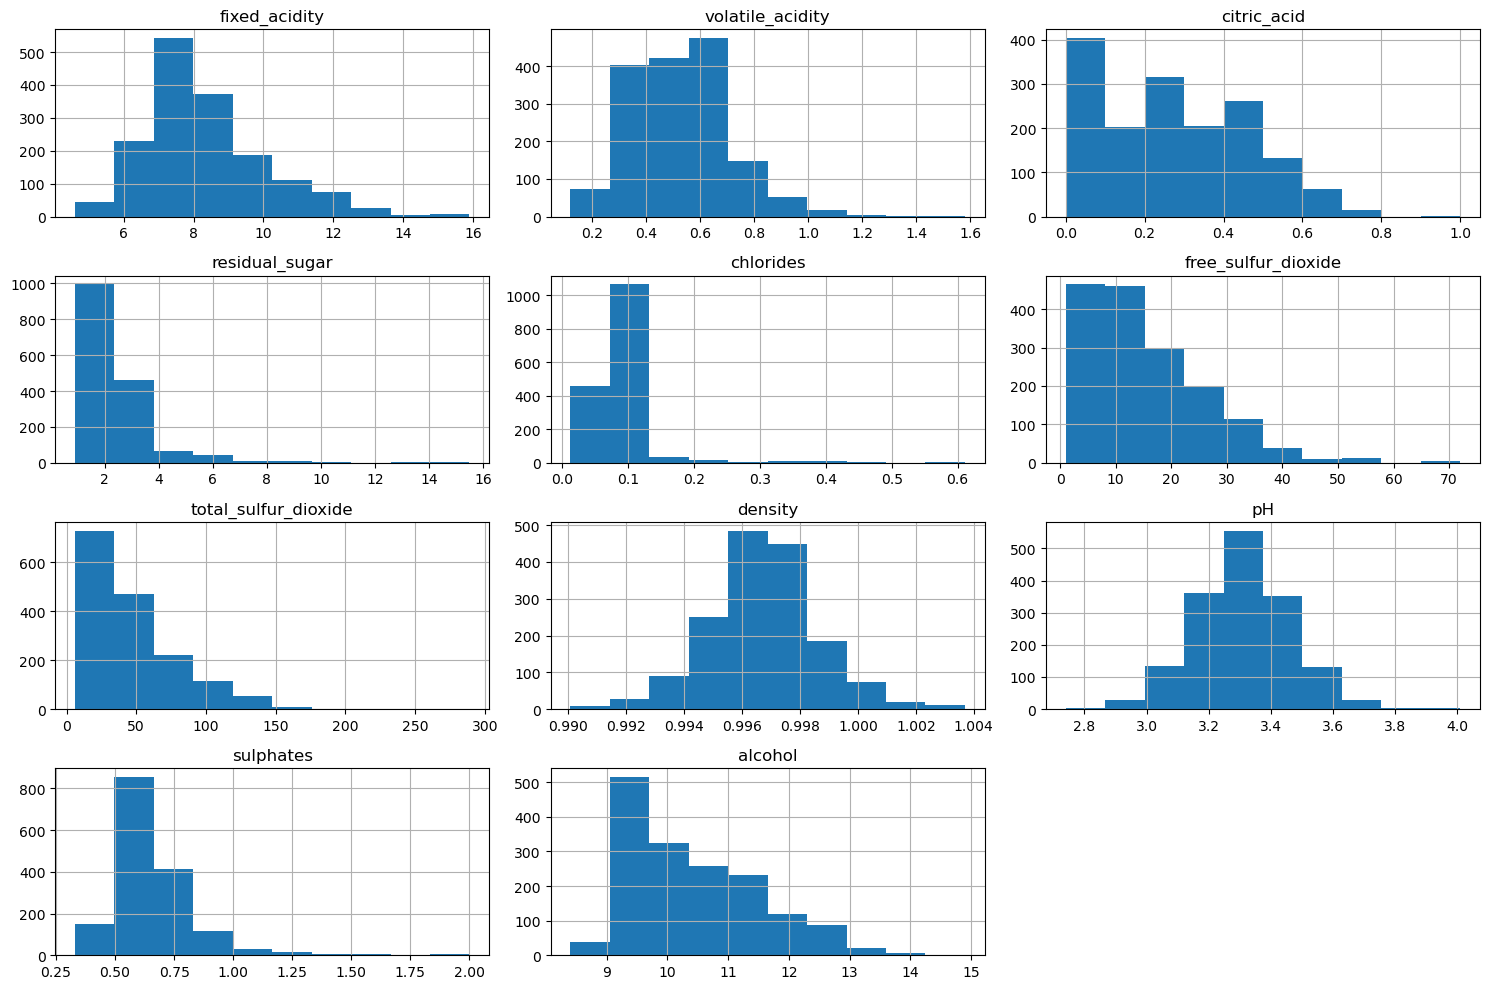

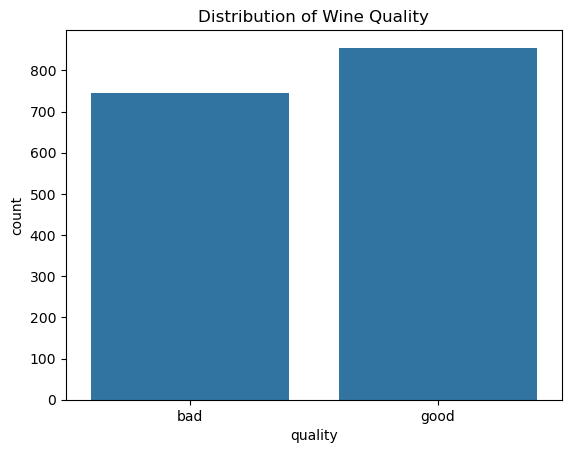

In [10]:
# Plot histograms for numerical variables
wine.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

# Plot countplot for the 'quality' variable
sns.countplot(x='quality', data=wine)
plt.title('Distribution of Wine Quality')
plt.show()

This dataset displays the distributions of 11 chemical features and the breakdown of wine quality. A key observation is the marked right-skewness (positive skewness) across the majority of the features (notably residual sugar, chlorides, and sulfur dioxide measures), indicating that most wines fall on the lower end of the scale for these values, with a small proportion of wines having very high concentrations. Conversely, variables like pH and density show a distribution closer to normal. For predictive modeling, the highly skewed variables will likely require logarithmic transformations to improve the performance of parametric models. The target variable, Quality, has been binarized into 'bad' and 'good' and shows a minimal imbalance (slightly more 'good' wines), which is manageable for most classification algorithms. In summary, the dataset is ready for correlation exploration (particularly with alcohol and volatile acidity, which often influence quality) and the feature engineering phase before commencing modeling.

In [11]:
wine.isnull().sum()

# that confirm that we don't have missing values

fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

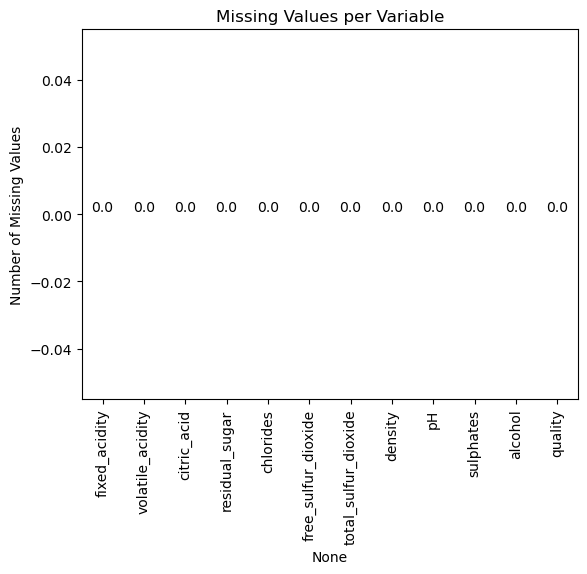

In [12]:
# Plot the sum of null values for each column
ax = sns.barplot(x=wine.columns, y=wine.isnull().sum())
plt.xticks(rotation=90)
plt.title('Missing Values per Variable')
plt.ylabel('Number of Missing Values')

# Add the count of missing values on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

# confirmation of non missing values

In [13]:
# Convert 'good' to 1 and 'bad' to 0 in the 'quality' column
wine['quality'] = wine['quality'].map({'good': 1, 'bad': 0})

In [15]:
# Display the first few rows to verify the change
wine.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


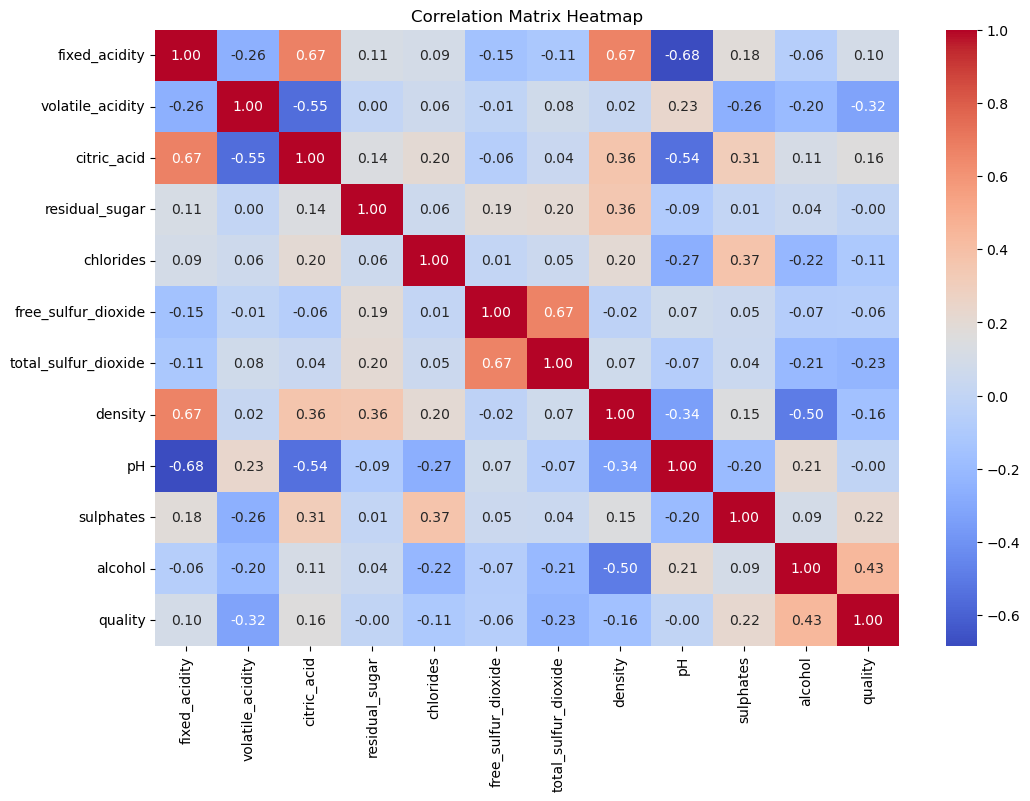

In [16]:
# Calculate the correlation matrix
correlation_matrix = wine.corr(numeric_only=True)

# Plot the correlation matrix heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

The simplest analysis focuses on correlations with the quality variable:

Positive correlations (factors improving quality):

Alcohol (+0.43): The strongest positive correlation — higher alcohol content is linked to better perceived quality.

Sulphates (+0.22): Also positively correlated with quality.

Citric acid (+0.16) and fixed_acidity(0.10) : Slight positive correlation.


Negative correlations (factors reducing quality):

Volatile acidity (−0.32): The strongest negative correlation — high volatile acidity (vinegar-like) greatly lowers quality.

Total sulfur dioxide (−0.23): Noticeable negative correlation.

Chlorides (−0.11): Slight negative effect on quality.

Relationships between chemical variables:

Fixed acidity is highly positively correlated with density (+0.67) and strongly negatively correlated with pH (−0.68), meaning higher acidity increases density and lowers pH — consistent with more acidic liquids.


The variables alcohol and volatile acidity are the most predictive of wine quality. An effective Machine Learning model should rely heavily on these two features.

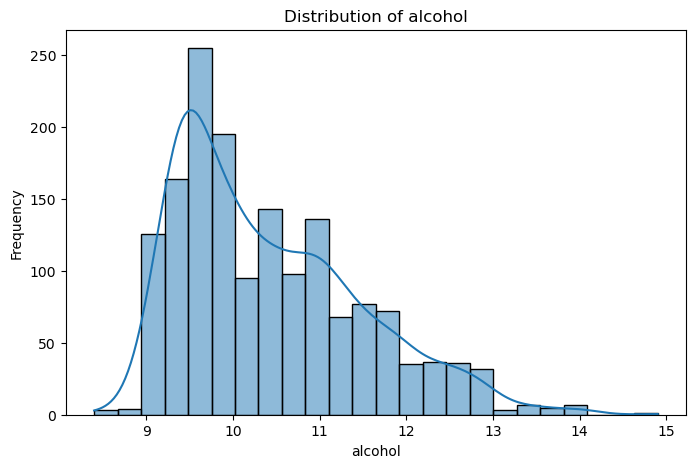

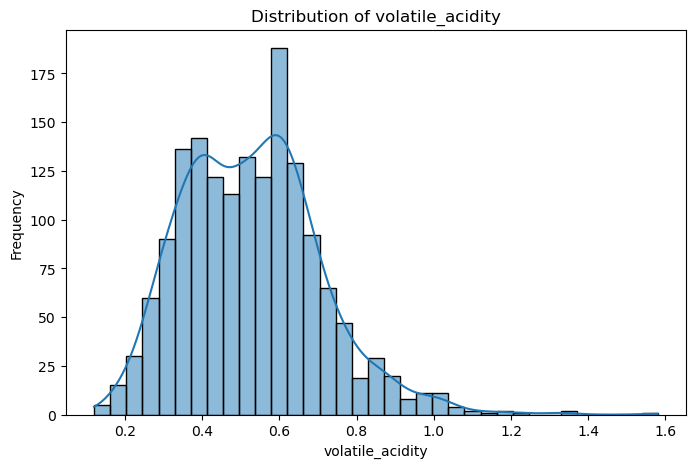

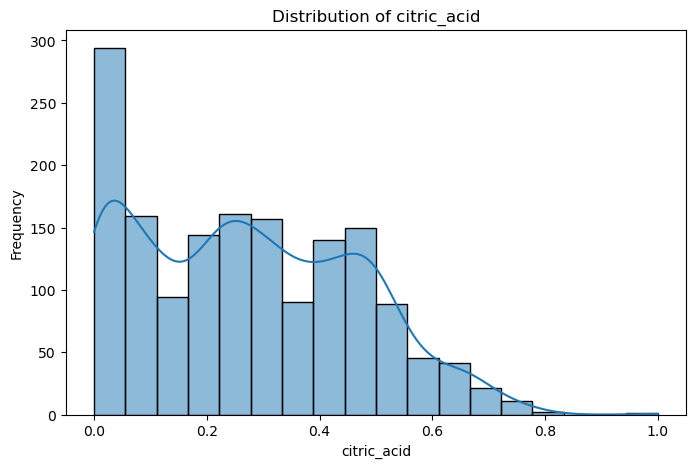

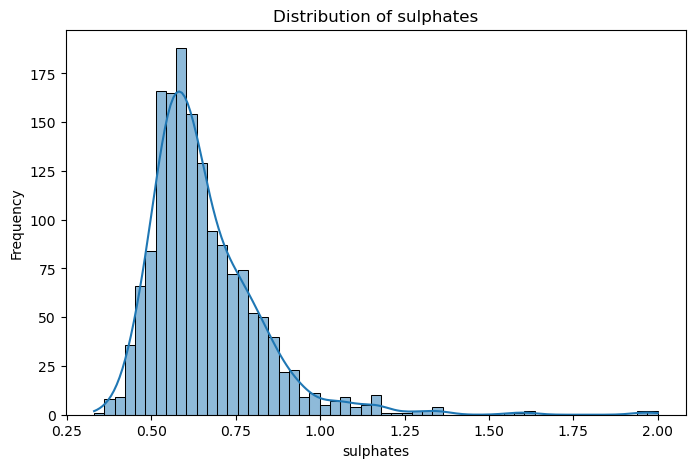

In [17]:
# Plot histograms for three features
features_to_plot = ['alcohol', 'volatile_acidity', 'citric_acid','sulphates'] # Selecting three features

for feature in features_to_plot:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=wine, x=feature, kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

Citric Acid (citric_acid)

Shape: Multimodal at the beginning, with several peaks. The highest peak is near zero (around 0.00–0.05), showing that many wines have very low or no citric acid content.

Trend: The distribution decreases irregularly as values increase.

Implication: The high number of zeros suggests two types of wines in the dataset — those with citric acid and those without, reflecting variability in production or composition.

Sulphates (sulphates)

Shape: Strongly right-skewed (positively skewed). Most values are low, with a main peak around 0.6–0.7.

Outliers: A long right tail shows a few wines with very high sulfate levels (up to 2.00+), indicating the presence of outliers.

Alcohol (alcohol)

Shape: Slightly left-skewed (negatively skewed), close to a normal bell curve.

Concentration: Most wines fall between 9.0% and 11.0%, with a main mode just below 10.0%.

Implication: This nearly normal distribution is ideal for regression models.

Volatile Acidity (volatile_acidity)

Shape: Slightly right-skewed (positively skewed). Values are concentrated between 0.3 and 0.7, with a distinct peak and a gradual decline after about 0.8.

Outliers: A few wines have very high volatile acidity, which is undesirable but rare.

Implication: The right tail reflects a small number of low-quality wines with excessive volatile acidity.

Model Building & Evaluation

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define features (X) and target (y)
X = wine.drop('quality', axis=1)
y = wine['quality']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(report)
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 0.740625
Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.76      0.72       141
           1       0.79      0.73      0.76       179

    accuracy                           0.74       320
   macro avg       0.74      0.74      0.74       320
weighted avg       0.75      0.74      0.74       320

Confusion Matrix:
[[107  34]
 [ 49 130]]


Let try to do some transformations and built a good model

The sulphates variable shows strong positive skewness (a long right tail) and contains extreme values. Logarithmic transformations are ideal to correct this type of skewness.This helps make the distribution closer to a normal curve, allows many models to learn relationships more effectively, and reduces the disproportionate impact of very high values (outliers).

Although the distributions of the variables are not all perfectly normal, it is still crucial to apply scaling to all features before training the model. This step is especially important for distance-based algorithms.

Scaling centers each variable around a mean of zero and gives it a standard deviation of one. This ensures that no variable — for example, total sulfur dioxide, which has relatively large values — dominates the learning process simply because of its scale.

In [19]:
# Transformation of sulphates in log
wine['sulphates_log'] = np.log(wine['sulphates'])

In [20]:
from sklearn.preprocessing import StandardScaler


In [21]:
wine.columns

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'sulphates_log'],
      dtype='object')

In [22]:
#  Split the target before the scaling
y = wine['quality']
X = wine.drop('quality', axis=1)

#  Applying scaling only in  X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#  Save the new dataframe scales in XX_scaled
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)


In [23]:
X_scaled

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,sulphates_log
0,-0.528360,0.961877,-1.391472,-0.453218,-0.243707,-0.466193,-0.379133,0.558274,1.288643,-0.579207,-0.960246,-0.602062
1,-0.298547,1.967442,-1.391472,0.043416,0.223875,0.872638,0.624363,0.028261,-0.719933,0.128950,-0.584777,0.266658
2,-0.298547,1.297065,-1.186070,-0.169427,0.096353,-0.083669,0.229047,0.134264,-0.331177,-0.048089,-0.584777,0.064774
3,1.654856,-1.384443,1.484154,-0.453218,-0.264960,0.107592,0.411500,0.664277,-0.979104,-0.461180,-0.584777,-0.445052
4,-0.528360,0.961877,-1.391472,-0.453218,-0.243707,-0.466193,-0.379133,0.558274,1.288643,-0.579207,-0.960246,-0.602062
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,-1.217796,0.403229,-0.980669,-0.382271,0.053845,1.542054,-0.075043,-0.978765,0.899886,-0.461180,0.072294,-0.445052
1595,-1.390155,0.123905,-0.877968,-0.240375,-0.541259,2.211469,0.137820,-0.862162,1.353436,0.601055,0.729364,0.764320
1596,-1.160343,-0.099554,-0.723916,-0.169427,-0.243707,1.255161,-0.196679,-0.533554,0.705508,0.542042,0.541630,0.705056
1597,-1.390155,0.654620,-0.775267,-0.382271,-0.264960,1.542054,-0.075043,-0.676657,1.677400,0.305990,-0.209308,0.459825


In [24]:
X_scaled.describe().round(2)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,sulphates_log
count,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00
mean,0.00,0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.14,-2.28,-1.39,-1.16,-1.60,-1.42,-1.23,-3.54,-3.70,-1.94,-1.90,-2.97
25%,-0.70,-0.77,-0.93,-0.45,-0.37,-0.85,-0.74,-0.61,-0.66,-0.64,-0.87,-0.68
50%,-0.24,-0.04,-0.06,-0.24,-0.18,-0.18,-0.26,0.00,-0.01,-0.23,-0.21,-0.15
75%,0.51,0.63,0.77,0.04,0.05,0.49,0.47,0.58,0.58,0.42,0.64,0.58
max,4.36,5.88,3.74,9.20,11.13,5.37,7.38,3.68,4.53,7.92,4.20,5.09


In [25]:
wine.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,sulphates_log
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,0.534709,-0.445260
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.498950,0.223566
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,0.000000,-1.108663
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,0.000000,-0.597837
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,1.000000,-0.478036
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,1.000000,-0.314711
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,1.000000,0.693147


In [26]:
X_scaled.columns

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'sulphates_log'],
      dtype='object')

In [40]:
# Define features (X) and target (y)
X = X_scaled.drop('sulphates', axis=1)
y = wine['quality']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(report)
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 0.74375
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.74      0.72       141
           1       0.79      0.74      0.76       179

    accuracy                           0.74       320
   macro avg       0.74      0.74      0.74       320
weighted avg       0.75      0.74      0.74       320

Confusion Matrix:
[[105  36]
 [ 46 133]]


After the preprocessing phase, which included applying a logarithmic transformation to the sulphates variable (to handle its skewness and dispersion) and performing Standard Scaling on all numerical features to bring them to the same scale, we trained the Logistic Regression model.
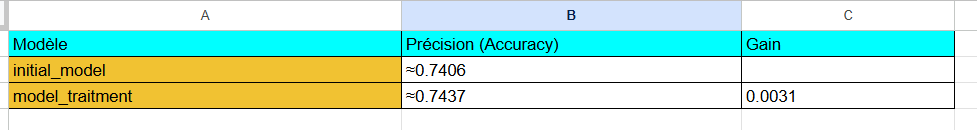

We observe a slight improvement in performance (an accuracy gain of 0.31%), indicating that the preprocessing had a positive, though minor, effect. However, this gain is quite small, suggesting that the Logistic Regression model quickly reaches its performance limit.

The Logistic Regression model tries to predict whether a wine is of Good Quality (Class 1) or Poor Quality (Class 0).

Overall Accuracy
Accuracy: 0.74375 (about 74%).
Simple Interpretation: The model makes the right decision about three times out of four.

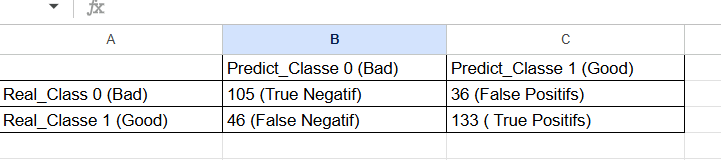


The Logistic Regression model aims to predict whether a wine is of Good Quality (Class 1) or Poor Quality (Class 0).

Overall Accuracy
Accuracy:0.74375 (about 74%).
Interpretation: The model makes the correct prediction about three times out of four. This shows a decent performance, though not perfect.

Precision (Reliability of the Prediction)
Class 1 (Good Wine): Precision =0.79.
Interpretation: When the model predicts that a wine is Good, it is correct 79% of the time and wrong 21% of the time. This is the model’s most reliable prediction.

Recall (Ability to Identify Good Wines)
Class 1 (Good Wine): Recall =0.74.
Interpretation: The model successfully identifies 74% of all truly Good Wines, but misses 26% of them (False Negatives).

F1-Score (Balance between Precision and Recall)
Value:0.76.
Interpretation: This score combines both Precision (0.79) and Recall (0.74). It shows that the model is solid and fairly balanced, but there is still room for improvement, particularly by increasing Recall without sacrificing too much Precision.

 Overall Summary:
The model is relatively balanced, but it tends to be slightly more precise (0.79) when identifying a good wine, at the cost of missing some (Recall = 0.74).
To further improve performance, it would be useful to reduce the 46 False Negatives and 36 False Positives.
The F1-Score of 0.76 confirms that the model performs well overall, though there is still some margin for improvement in achieving a better trade-off between detection and reliability.

In [28]:
y = wine['quality']
print(y.unique())


[0 1]


In [29]:
wine['quality'].describe()


count    1599.000000
mean        0.534709
std         0.498950
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: quality, dtype: float64

In [30]:
wine['quality'].value_counts().sort_index()

quality
0    744
1    855
Name: count, dtype: int64

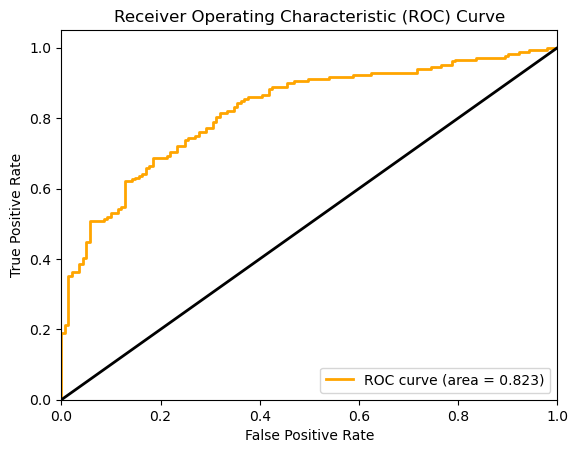

AUC: 0.8227742779032451


In [46]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Re-initialize and train the Logistic Regression model
X = X_scaled.drop('sulphates', axis=1)
y = wine['quality']

# Split data into training and testing sets (same split as before for consistency)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


# Get predicted probabilities for the positive class (class 1)
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='orange', lw=2, label='ROC curve (area = %0.3f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='-')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

print(f"AUC: {roc_auc}")

1. Graph Interpretation

Y-Axis (True Positive Rate – TPR / Recall):
Represents the proportion of Good Quality wines correctly identified. This is what we want to maximize.

X-Axis (False Positive Rate – FPR):
Represents the proportion of Poor Quality wines incorrectly labeled as Good. This is what we want to minimize.

Black Diagonal (Baseline):
Represents a classifier that makes random decisions (like flipping a coin).
A useful model should always perform above this line.

Orange Curve:
Shows the actual performance of your model.
The curve rises sharply toward the upper-left corner, indicating that the model achieves a high True Positive Rate (TPR) while keeping False Positives (FPR) low.

Conclusion: The model shows a good ability to discriminate between good and poor wines.

2. Interpretation of the AUC Value

The AUC (Area Under the Curve) represents the area under the ROC curve. It summarizes the model’s overall performance in a single number.

Displayed Value: 82 (approximately 0.8227742779032451)

Theoretical Meaning:
AUC measures the probability that the model assigns a higher score to a randomly chosen Good Wine than to a Poor Wine.

Practical Interpretation:
A score of 0.82 indicates very good performance.

After the logistic regression model tel create a RandomForest and K-Nearest Neighbors  to see if we are able to maximize the accuracy of the model because check the quality of a wine means clustering 

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define features (X) and target (y) using the scaled data
X = X_scaled.drop('sulphates', axis=1)
y = wine['quality']

# Split data into training and testing sets (same split as before for consistency)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf}")
print("Random Forest Classification Report:")
print(report_rf)
print("Random Forest Confusion Matrix:")
print(conf_matrix_rf)

Random Forest Accuracy: 0.8
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.77      0.77       141
           1       0.82      0.82      0.82       179

    accuracy                           0.80       320
   macro avg       0.80      0.80      0.80       320
weighted avg       0.80      0.80      0.80       320

Random Forest Confusion Matrix:
[[109  32]
 [ 32 147]]


In [41]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define features (X) and target (y) using the scaled data
X = X_scaled.drop('sulphates', axis=1)
y = wine['quality']

# Split data into training and testing sets (same split as before for consistency)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the K-Nearest Neighbors model
# Using n_neighbors=5 as a starting point, this can be tuned later
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test)

# Evaluate the model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
report_knn = classification_report(y_test, y_pred_knn)
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)

print(f"K-Nearest Neighbors Accuracy: {accuracy_knn}")
print("K-Nearest Neighbors Classification Report:")
print(report_knn)
print("K-Nearest Neighbors Confusion Matrix:")
print(conf_matrix_knn)

K-Nearest Neighbors Accuracy: 0.721875
K-Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.62      0.66       141
           1       0.73      0.80      0.76       179

    accuracy                           0.72       320
   macro avg       0.72      0.71      0.71       320
weighted avg       0.72      0.72      0.72       320

K-Nearest Neighbors Confusion Matrix:
[[ 88  53]
 [ 36 143]]


Using the two new nested models, we observe that the Random Forest model, with approximately 80% accuracy, is more robust and has a superior ability to generalize the results compared to K-Nearest Neighbors and our baseline model, logistic regression. However, although K-Nearest Neighbors is robust with 72% prediction accuracy, it shows a weaker performance compared to our baseline model.  Regarding RMSE and MSE, the Random Forest model performs best, followed by our baseline logistic regression model, and finally K-Nearest Neighbors.